Project-2

Detecting malaria with deep learning (CNN)

To Run 
1. Mount drive 
2. Train model (two options are available)
  
  * Choose A to establish new training models
  * Choose B to continue training models

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [2]:
# Importing the Keras libraries and packages
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout
from keras.preprocessing.image import ImageDataGenerator
from imutils import paths
from collections import Counter
from keras.callbacks import ModelCheckpoint
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
from keras.models import load_model
import tensorflow as tf

#tf.test.gpu_device_name()

Using TensorFlow backend.


In [0]:
# our images after computing the training and testing split
BASE_PATH = "/content/drive/My Drive/ColabNotebooks/datasets/cell_images"

# derive the training, validation, and testing directories
TRAIN_PATH = os.path.sep.join([BASE_PATH, "training"])
VAL_PATH = os.path.sep.join([BASE_PATH, "validation"])
TEST_PATH = os.path.sep.join([BASE_PATH, "testing"])

# determine the total number of image paths in training, validation,
# and testing directories
totalTrain = len(list(paths.list_images(TRAIN_PATH)))
totalVal = len(list(paths.list_images(VAL_PATH)))
totalTest = len(list(paths.list_images(TEST_PATH)))


In [4]:
print(totalTrain)
print(totalVal)
print(totalTest)

19842
2204
5512


In [0]:
# define the total number of epochs to train for along with the
# initial learning rate and batch size
NUM_EPOCHS = 50
#INIT_LR = 1e-2
BS = 32

## Data Preprocessing

In [0]:
# initialize the training data augmentation object
trainAug = ImageDataGenerator(
	rescale=1 / 255.0,
	rotation_range=20,
	zoom_range=0.05,
	width_shift_range=0.05,
	height_shift_range=0.05,
	shear_range=0.05,
	horizontal_flip=True,
	fill_mode="nearest")
 
# initialize the validation (and testing) data augmentation object
valAug = ImageDataGenerator(rescale=1 / 255.0)

In [31]:
# initialize the training generator
trainGen = trainAug.flow_from_directory(
	TRAIN_PATH,
	class_mode="categorical",
	target_size=(64, 64),
	color_mode="rgb",
	shuffle=True,
	batch_size=BS)

# initialize the validation generator
valGen = valAug.flow_from_directory(
	VAL_PATH,
	class_mode="categorical",
	target_size=(64, 64),
	color_mode="rgb",
	shuffle=False,
	batch_size=BS)

# initialize the testing generator
testGen = valAug.flow_from_directory(
	TEST_PATH,
	class_mode="categorical",
	target_size=(64, 64),
	color_mode="rgb",
	shuffle=False,
	batch_size=BS)

Found 19842 images belonging to 2 classes.
Found 2204 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.


## Initialising the CNN

### A) Start a new training 

In [0]:
# Initialising the CNN
classifier = Sequential()

# Step 1 - Convolution
classifier.add(Conv2D(32, (3, 3), input_shape = (64, 64, 3),
                      activation = 'relu'))
classifier.add(MaxPooling2D(pool_size = (2, 2)))

# Adding a second convolutional layer
classifier.add(Conv2D(64, (3, 3), 
                      activation = 'relu'))
classifier.add(MaxPooling2D(pool_size = (2, 2)))

# Adding a third convolutional layer
classifier.add(Conv2D(128, (3, 3),
                      activation = 'relu'))
classifier.add(MaxPooling2D(pool_size = (2, 2)))

# Step 3 - Flattening
classifier.add(Flatten())

# Step 4 - Full connection
classifier.add(Dense(units = 128, activation = 'relu'))
classifier.add(Dropout(0.3) )

classifier.add(Dense(units = 128, activation = 'relu'))
classifier.add(Dropout(0.3) )

classifier.add(Dense(units = 2,
                     activation = 'sigmoid'))
## Compiling the CNN
classifier.compile(optimizer = 'adam',
                   loss = 'binary_crossentropy', 
                   metrics = ['accuracy'])

In [0]:
## Checkpoint
## Colab allows us to use GPU/TPU only 12 hours for free, then we must use a checkpoint strategy

## 1)  for latest best model only not every step of improvement
filepath="/content/drive/My Drive/ColabNotebooks/checkpoint/project2-weights.best.hdf5" 

## 2)  for every step of improvement
## filepath="/content/drive/My Drive/ColabNotebooks/checkpoint/project2-weights-improvement-{epoch:02d}-{val_acc:.2f}.hdf5"

checkpoint = ModelCheckpoint(filepath, monitor='val_acc',
                             verbose=1, save_best_only=True,
                             mode='max')
callbacks_list = [checkpoint]

## Start Training
history = classifier.fit_generator(trainGen,
                         steps_per_epoch = totalTrain  // BS,
                         epochs = NUM_EPOCHS,
                         validation_data = valGen,
                         validation_steps = totalVal  // BS,
                         callbacks=callbacks_list)


Epoch 1/50
620/620 [==============================] - 5930s 10s/step - loss: 0.3587 - acc: 0.8289 - val_loss: 0.1586 - val_acc: 0.9566

Epoch 00001: val_acc improved from -inf to 0.95657, saving model to /content/drive/My Drive/ColabNotebooks/checkpoint/project2-weights.best.hdf5
Epoch 2/50
620/620 [==============================] - 205s 330ms/step - loss: 0.1667 - acc: 0.9493 - val_loss: 0.1415 - val_acc: 0.9553

Epoch 00002: val_acc did not improve from 0.95657
Epoch 3/50
620/620 [==============================] - 213s 343ms/step - loss: 0.1520 - acc: 0.9523 - val_loss: 0.1294 - val_acc: 0.9590

Epoch 00003: val_acc improved from 0.95657 to 0.95902, saving model to /content/drive/My Drive/ColabNotebooks/checkpoint/project2-weights.best.hdf5
Epoch 4/50
620/620 [==============================] - 213s 344ms/step - loss: 0.1469 - acc: 0.9530 - val_loss: 0.1326 - val_acc: 0.9540

Epoch 00004: val_acc did not improve from 0.95902
Epoch 5/50
620/620 [==============================] - 213s 3

### B) For continuing training 




In [0]:
## Load the model we saved
## To to use pre-exits model  
classifier = load_model('/content/drive/My Drive/ColabNotebooks/checkpoint/project2-weights.best.hdf5')

## 1) For latest best model only not every step of improvement
filepath="/content/drive/My Drive/ColabNotebooks/checkpoint/project2-weights.best.hdf5" 

## 2) For every step of improvement
## filepath="/content/drive/My Drive/ColabNotebooks/checkpoint/project2-weights-improvement-{epoch:02d}-{val_acc:.2f}.hdf5"

checkpoint = ModelCheckpoint(filepath, monitor='val_acc',
                             verbose=1, save_best_only=True,
                             mode='max')
callbacks_list = [checkpoint]

## Start Training
history = classifier.fit_generator(trainGen,
                         steps_per_epoch = totalTrain  // BS,
                         epochs = NUM_EPOCHS,
                         validation_data = valGen,
                         validation_steps = totalVal  // BS,
                         callbacks=callbacks_list)

Epoch 1/50
620/620 [==============================] - 214s 345ms/step - loss: 0.0892 - acc: 0.9708 - val_loss: 0.1165 - val_acc: 0.9697

Epoch 00001: val_acc improved from -inf to 0.96967, saving model to /content/drive/My Drive/ColabNotebooks/checkpoint/project2-weights.best.hdf5
Epoch 2/50
620/620 [==============================] - 213s 344ms/step - loss: 0.0838 - acc: 0.9707 - val_loss: 0.1154 - val_acc: 0.9632

Epoch 00002: val_acc did not improve from 0.96967
Epoch 3/50
620/620 [==============================] - 212s 341ms/step - loss: 0.0853 - acc: 0.9706 - val_loss: 0.1139 - val_acc: 0.9641

Epoch 00003: val_acc did not improve from 0.96967
Epoch 4/50
620/620 [==============================] - 203s 327ms/step - loss: 0.0839 - acc: 0.9715 - val_loss: 0.1113 - val_acc: 0.9664

Epoch 00004: val_acc did not improve from 0.96967
Epoch 5/50
620/620 [==============================] - 215s 346ms/step - loss: 0.0835 - acc: 0.9714 - val_loss: 0.1268 - val_acc: 0.9636

Epoch 00005: val_acc

In [0]:
# Finish Time
import datetime
print(datetime.datetime.now())

2019-11-02 03:07:28.353914


## Evaluation

Test with testing sets

In [0]:
# reset the testing generator and then use our trained model to
# make predictions on the data
print("[INFO] evaluating network...")
testGen.reset()
predIdxs = classifier.predict_generator(testGen,
	steps=(totalTest // BS) + 1,verbose=1)
 
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
 
# show a nicely formatted classification report
print(classification_report(testGen.classes, predIdxs,
	target_names=testGen.class_indices.keys()))


[INFO] evaluating network...
173/173 [==============================] - 1564s 9s/step
              precision    recall  f1-score   support

 parasitized       0.98      0.96      0.97      2726
  uninfected       0.96      0.98      0.97      2786

    accuracy                           0.97      5512
   macro avg       0.97      0.97      0.97      5512
weighted avg       0.97      0.97      0.97      5512



Test with single image

{'parasitized': 0, 'uninfected': 1}
uninfected


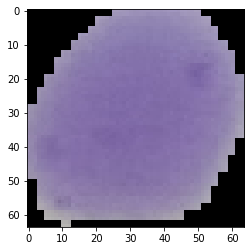

In [38]:
from keras.preprocessing import image
import matplotlib.pyplot as plt

def prepare(filepath):
    test_image = image.load_img(filepath, target_size = (64, 64))
    test_image = image.img_to_array(test_image)
    plt.imshow(test_image/255)
    test_image = np.expand_dims(test_image, axis = 0)
    test_image = np.multiply(test_image, 1.0/255.0) 
    return test_image

result=classifier.predict(prepare("/content/drive/My Drive/ColabNotebooks/datasets/cell_images/testing/uninfected/C240ThinF_IMG_20151127_115306_cell_75.png"))
trainGen.class_indices
# print(trainGen.class_indices) {'parasitized': 0, 'uninfected': 1}
if result[0][0] == 1:
    
    prediction = 'infected'
else:
    prediction = 'uninfected'

print(prediction)


infected


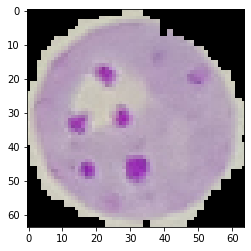

In [37]:
result=classifier.predict(prepare("/content/drive/My Drive/ColabNotebooks/datasets/cell_images/testing/parasitized/C183P144NThinF_IMG_20151201_224458_cell_122.png"))
trainGen.class_indices
if result[0][0] == 1:
    prediction = 'infected'
else:
     prediction = 'uninfected'

print(prediction)

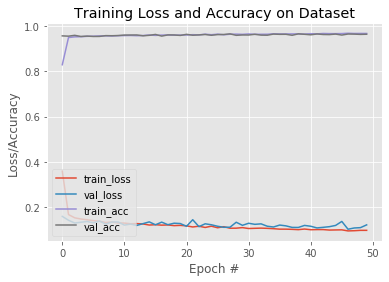

In [0]:
# plot the training loss and accuracy

N = NUM_EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), history.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), history.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), history.history["acc"], label="train_acc")
plt.plot(np.arange(0, N), history.history["val_acc"], label="val_acc")
plt.title("Training Loss and Accuracy on Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
plt.savefig("plot.png")



Plot Model

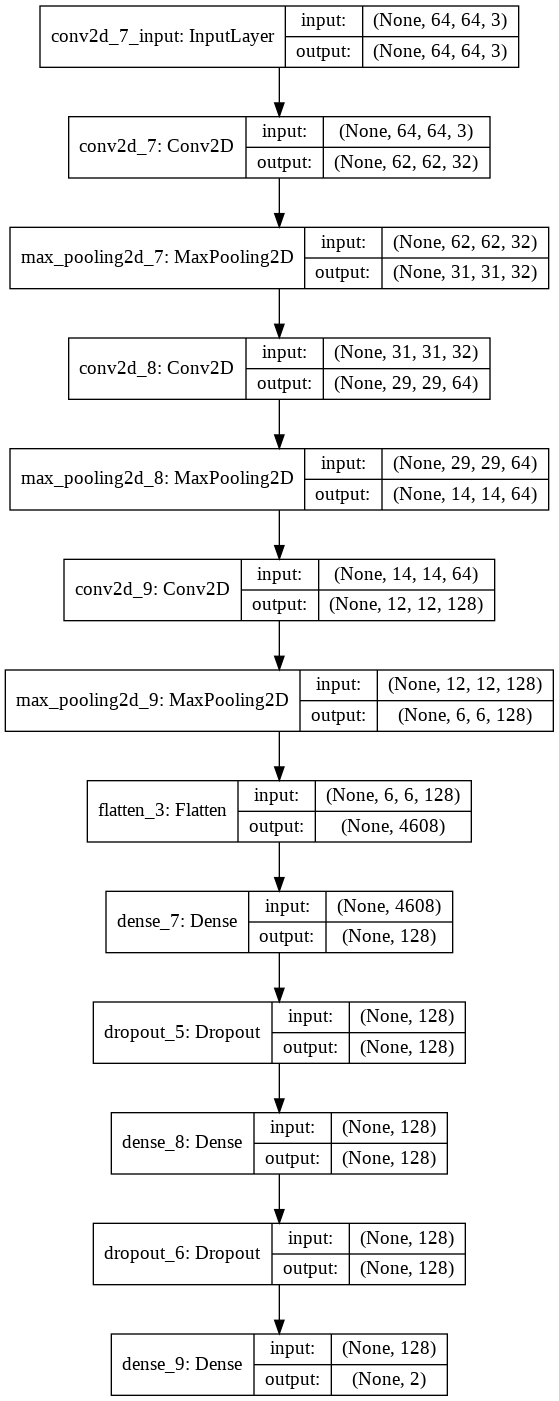

In [0]:
from keras.utils import plot_model
plot_model(classifier, show_shapes=True, show_layer_names=True)